# Project 3 — Deep Learning Application (Computer Vision)

Objective: Prove proficiency with a deep learning framework (PyTorch) using transfer learning.

Approach: Take a ResNet50 pretrained on ImageNet, replace its final classification layer, and fine-tune it to classify chest X-rays as NORMAL or PNEUMONIA. Includes early stopping and learning rate scheduling, as required by the checklist.

Dataset: Kaggle "Chest X-Ray Images (Pneumonia)" — download it from Kaggle and unzip it so you have this folder structure next to this notebook:

```
chest_xray/
├── train/
│   ├── NORMAL/
│   └── PNEUMONIA/
├── val/
│   ├── NORMAL/
│   └── PNEUMONIA/
└── test/
    ├── NORMAL/
    └── PNEUMONIA/
```

That's exactly how the Kaggle download is already structured, so no reorganizing needed.

In [2]:
import sys
!{sys.executable} -m pip install torch torchvision scikit-learn matplotlib

   ---------------------------------------- 0.0/123.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/123.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/123.0 MB ? eta -:--:--
   ---------------------------------------- 0.3/123.0 MB ? eta -:--:--
   ---------------------------------------- 0.3/123.0 MB ? eta -:--:--
   ---------------------------------------- 0.3/123.0 MB ? eta -:--:--
   ---------------------------------------- 0.3/123.0 MB ? eta -:--:--
   ---------------------------------------- 0.5/123.0 MB 279.8 kB/s eta 0:07:18
   ---------------------------------------- 0.5/123.0 MB 279.8 kB/s eta 0:07:18
   ---------------------------------------- 0.5/123.0 MB 279.8 kB/s eta 0:07:18
   ---------------------------------------- 0.8/123.0 MB 353.3 kB/s eta 0:05:46
   ---------------------------------------- 0.8/123.0 MB 353.3 kB/s eta 0:05:46
   ---------------------------------------- 1.0/123.0 MB 409.2 kB/s eta 0:04:59
   --------------------

In [3]:
import copy
import time

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.utils.data import DataLoader
from torchvision import datasets, models, transforms

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


## 1. Data loading and augmentation

Training data gets light augmentation (random flip/rotation) to help generalization. Validation and test data are only resized and normalized — never augmented, since we want a clean, honest evaluation.

In [4]:
DATA_DIR = "chest_xray"
IMG_SIZE = 224
BATCH_SIZE = 32

# ImageNet normalization stats -- required because we're using an ImageNet-pretrained model
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std),
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std),
])

train_dataset = datasets.ImageFolder(f"{DATA_DIR}/train", transform=train_transform)
val_dataset = datasets.ImageFolder(f"{DATA_DIR}/val", transform=eval_transform)
test_dataset = datasets.ImageFolder(f"{DATA_DIR}/test", transform=eval_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

class_names = train_dataset.classes
print("Classes:", class_names)
print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")

Classes: ['NORMAL', 'PNEUMONIA']
Train: 5216 | Val: 16 | Test: 624


## 2. Build the model — transfer learning with ResNet50

We load ResNet50 with ImageNet weights, freeze the early convolutional layers (they already know general image features like edges and textures), and only replace + train the final classification layer for our 2-class problem. This is much faster and needs far less data than training from scratch.

In [5]:
model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)

# Freeze all the pretrained layers
for param in model.parameters():
    param.requires_grad = False

# Replace the final fully-connected layer for binary classification.
# This new layer is NOT frozen, so it's the only part that gets trained.
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, len(class_names))

model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=1e-3)

# Reduce the learning rate when validation loss stops improving
scheduler = ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=2)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to C:\Users\jesut/.cache\torch\hub\checkpoints\resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:59<00:00, 1.74MB/s]


## 3. Training loop with early stopping

Early stopping means: if validation loss doesn't improve for `PATIENCE` epochs in a row, stop training and keep the best-performing weights seen so far — this prevents overfitting from training too long.

In [6]:
NUM_EPOCHS = 15
PATIENCE = 4

train_losses, val_losses = [], []
best_val_loss = float("inf")
best_model_weights = copy.deepcopy(model.state_dict())
epochs_no_improve = 0

for epoch in range(NUM_EPOCHS):
    start = time.time()

    # --- Training phase ---
    model.train()
    running_loss = 0.0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * inputs.size(0)
    epoch_train_loss = running_loss / len(train_dataset)

    # --- Validation phase ---
    model.eval()
    running_val_loss = 0.0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            running_val_loss += loss.item() * inputs.size(0)
    epoch_val_loss = running_val_loss / len(val_dataset)

    train_losses.append(epoch_train_loss)
    val_losses.append(epoch_val_loss)
    scheduler.step(epoch_val_loss)

    elapsed = time.time() - start
    print(f"Epoch {epoch+1}/{NUM_EPOCHS} | train_loss={epoch_train_loss:.4f} | "
          f"val_loss={epoch_val_loss:.4f} | lr={optimizer.param_groups[0]['lr']:.6f} | {elapsed:.1f}s")

    # --- Early stopping check ---
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        best_model_weights = copy.deepcopy(model.state_dict())
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= PATIENCE:
            print(f"Early stopping triggered after epoch {epoch+1} (no improvement for {PATIENCE} epochs)")
            break

# Restore the best weights seen during training, not just the last epoch's weights
model.load_state_dict(best_model_weights)

Epoch 1/15 | train_loss=0.2916 | val_loss=0.6415 | lr=0.001000 | 1176.1s
Epoch 2/15 | train_loss=0.1863 | val_loss=0.5103 | lr=0.001000 | 988.5s
Epoch 3/15 | train_loss=0.1595 | val_loss=0.6186 | lr=0.001000 | 942.2s
Epoch 4/15 | train_loss=0.1521 | val_loss=0.7310 | lr=0.001000 | 949.7s
Epoch 5/15 | train_loss=0.1439 | val_loss=0.5366 | lr=0.000500 | 942.8s
Epoch 6/15 | train_loss=0.1302 | val_loss=0.5874 | lr=0.000500 | 964.6s
Early stopping triggered after epoch 6 (no improvement for 4 epochs)


<All keys matched successfully>

## 4. Training vs validation loss curve

This is a required deliverable — it's the visual proof the model is learning without overfitting (if validation loss starts climbing while training loss keeps dropping, that's overfitting).

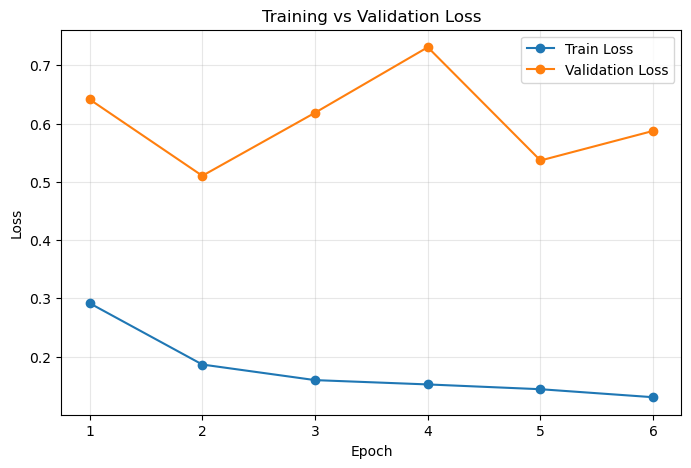

In [7]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(train_losses) + 1), train_losses, label="Train Loss", marker="o")
plt.plot(range(1, len(val_losses) + 1), val_losses, label="Validation Loss", marker="o")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.savefig("training_validation_loss.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Final evaluation on the held-out test set

The test set was never touched during training or early stopping — this is the honest, final performance number.

              precision    recall  f1-score   support

      NORMAL       0.89      0.64      0.74       234
   PNEUMONIA       0.81      0.95      0.88       390

    accuracy                           0.83       624
   macro avg       0.85      0.80      0.81       624
weighted avg       0.84      0.83      0.83       624



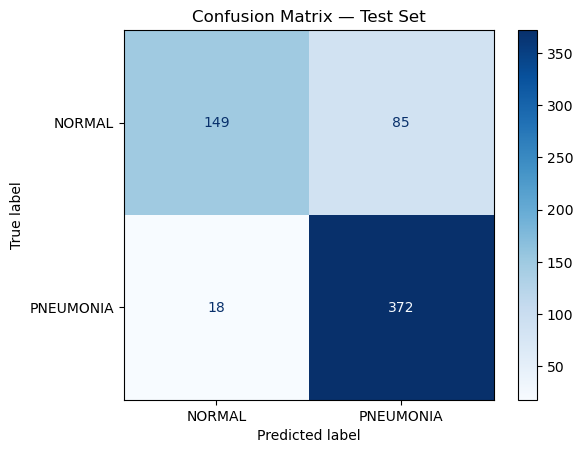

In [8]:
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        preds = torch.argmax(outputs, dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

print(classification_report(all_labels, all_preds, target_names=class_names))

cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix — Test Set")
plt.savefig("confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Save the trained model

This saved `.pth` file is what Project 4 (Model Optimization) will load and convert to ONNX.

In [9]:
torch.save(model.state_dict(), "resnet50_pneumonia.pth")
print("Model saved to resnet50_pneumonia.pth")

Model saved to resnet50_pneumonia.pth
